<a href="https://colab.research.google.com/github/tusharpatil578/Yulu_Case_Study/blob/main/Yulu_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**About** **Yulu**

Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.

Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient!

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.

**TASK AT HAND:**

The company wants to know:

Which variables are significant in predicting the demand for shared electric cycles in the Indian market?
How well those variables describe the electric cycle demands

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway # One-way ANOVA
from scipy.stats import kruskal
from scipy.stats import chi2_contingency

In [ ]:
url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv?1642089089"
df = pd.read_csv(url)
print(df.head())

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


In [ ]:
df.shape

(10886, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
df.isnull().count()

,0
datetime,10886
season,10886
holiday,10886
workingday,10886
weather,10886
temp,10886
atemp,10886
humidity,10886
windspeed,10886
casual,10886


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
10881,False
10882,False
10883,False
10884,False


In [ ]:
column_list=["season","holiday","workingday","weather"]
for items in column_list:
  print(f"Column Name: {items}")
  print("Unique values",df[items].unique())
  print("Value coounts", df[items].value_counts())
  print("-------"*15)


Column Name: season
Unique values [1 2 3 4]
Value coounts season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------------
Column Name: holiday
Unique values [0 1]
Value coounts holiday
0    10575
1      311
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------------
Column Name: workingday
Unique values [0 1]
Value coounts workingday
1    7412
0    3474
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------------
Column Name: weather
Unique values [1 2 3 4]
Value coounts weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------------


In [ ]:
df_only_numerical_val=df.select_dtypes(include=["float","int"])
df_only_numerical_val

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [ ]:
df_categorical = df.select_dtypes(include=["object"])
df_categorical

,datetime
0,2011-01-01 00:00:00
1,2011-01-01 01:00:00
2,2011-01-01 02:00:00
3,2011-01-01 03:00:00
4,2011-01-01 04:00:00
...,...
10881,2012-12-19 19:00:00
10882,2012-12-19 20:00:00
10883,2012-12-19 21:00:00
10884,2012-12-19 22:00:00


Text(0.5, 1.0, 'Proportional Distribution of Seasons in Dataset')

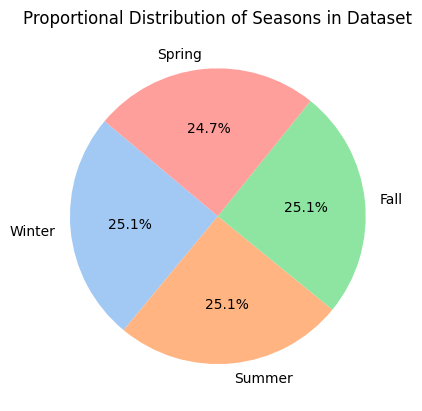

In [ ]:
# 1. Calculating the frequency distribution of the categorical variable
season_counts = df['season'].value_counts()

# 2. Mapping the numerical codes to descriptive text labels for better readability
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
labels = [season_mapping[index] for index in season_counts.index]

# 3. Creating the pie chart
plt.pie(
    season_counts,
    labels=labels,
    autopct='%1.1f%%',       # Displays the percentage on each wedge
    startangle=140,          # Rotates the start of the pie chart for better alignment
    colors=sns.color_palette('pastel') # Uses a clean seaborn color palette
)
plt.title('Proportional Distribution of Seasons in Dataset')

Text(0.5, 1.0, 'Distribution of Weather Conditions')

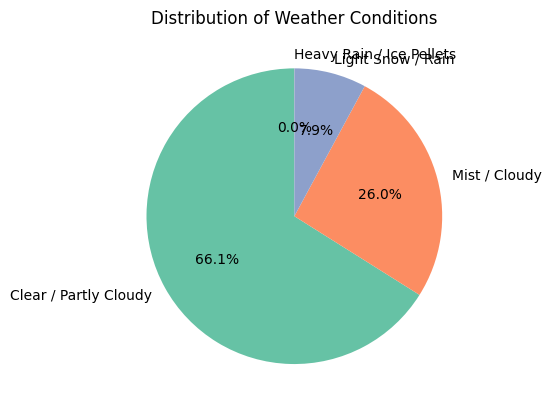

In [ ]:
# 1. Calculating frequency distribution
weather_counts = df['weather'].value_counts()

# 2. Mapping numerical codes to weather descriptions
weather_mapping = {
    1: 'Clear / Partly Cloudy',
    2: 'Mist / Cloudy',
    3: 'Light Snow / Rain',
    4: 'Heavy Rain / Ice Pellets'
}
labels = [weather_mapping[idx] for idx in weather_counts.index]

# 3. Creating the pie chart
plt.pie(
    weather_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2')
)
plt.title('Distribution of Weather Conditions')

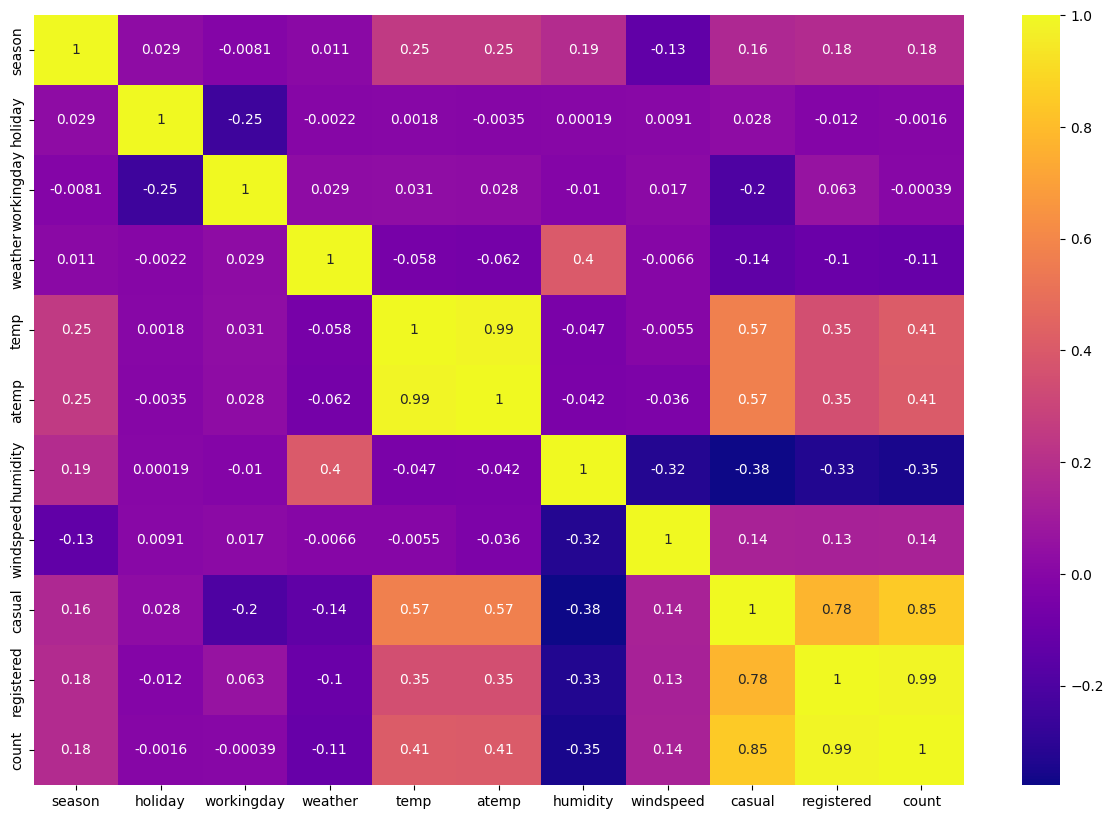

In [ ]:
plt.figure(figsize=(15, 10)) ## This define my canvas size.
sns.heatmap(df_only_numerical_val.corr(method='spearman'),
            annot=True, cmap='plasma')
plt.show()

As the data has some columns which are either too similar or almost same as other columns we will drop those columns.

In [ ]:
df_after_drop=df.drop(columns=['casual','temp','registered'])
df_after_drop.head()

,datetime,season,holiday,workingday,weather,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,14.395,81,0.0,16
1,2011-01-01 01:00:00,1,0,0,1,13.635,80,0.0,40
2,2011-01-01 02:00:00,1,0,0,1,13.635,80,0.0,32
3,2011-01-01 03:00:00,1,0,0,1,14.395,75,0.0,13
4,2011-01-01 04:00:00,1,0,0,1,14.395,75,0.0,1


/tmp/ipykernel_3775/1339133656.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_after_drop['count'],bins=8)


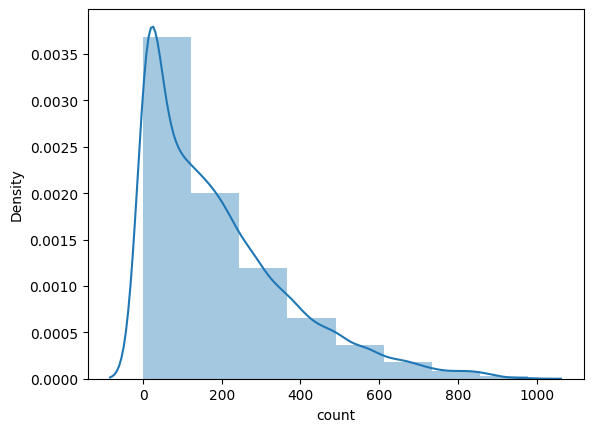

In [ ]:
sns.distplot(df_after_drop['count'],bins=8)
plt.show()

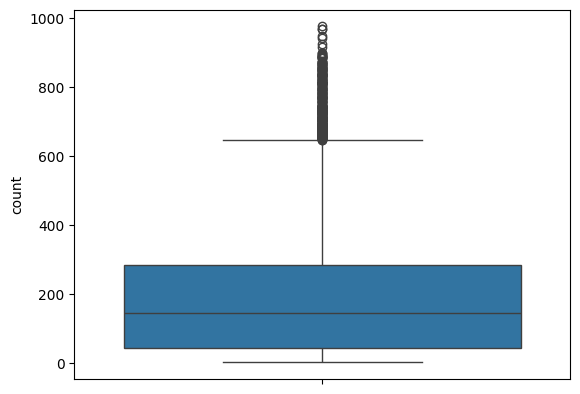

In [ ]:
sns.boxplot(y=df_after_drop['count'])
plt.show()

/tmp/ipykernel_3775/755671934.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df_after_drop['count']),bins=10)


<Axes: xlabel='count', ylabel='Density'>

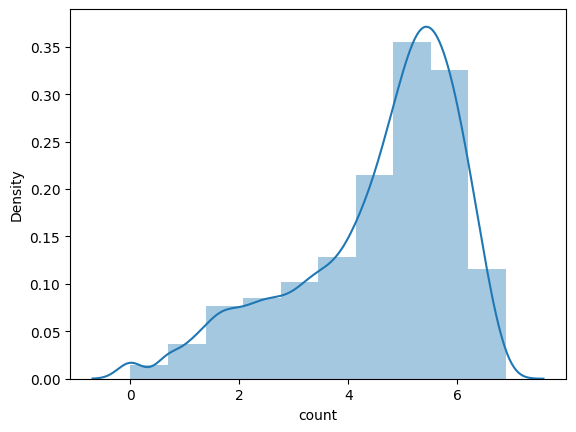

In [ ]:
sns.distplot(np.log(df_after_drop['count']),bins=10)

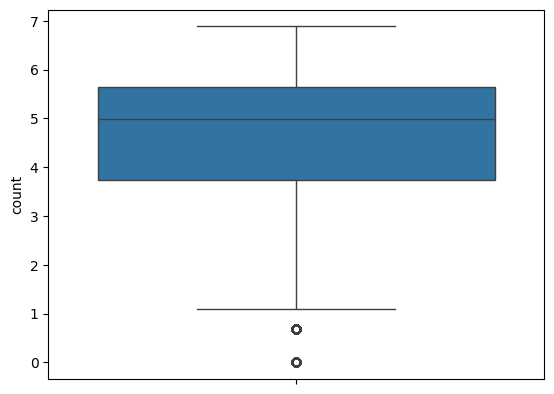

In [ ]:
sns.boxplot(y=np.log(df_after_drop['count']))
plt.show()

**Problem 1: Are the bike rides on weekdays significantly smaller than those on weekends?**

$H_0:$ The demand of bikes on weekdays is greater or similar to the demand of bikes on weekend.

$H_a:$ The demand of bikes on weekdays is less than the demand of bikes on weekend.

Let $\mu_1$ and $\mu_2$ be the average no. of bikes rented on weekdays and weekends respectively.

Mathematically, the above formulated hypothesis can be written as:

$H_0: \mu_1 >= \mu_2$

$H_a: \mu_1 < \mu_2$

In [ ]:
df_after_drop['workingday'].unique()

array([0, 1])

In [ ]:
df_after_drop['workingday'].value_counts()

,count
workingday,
1,7412
0,3474


In [ ]:
weekday=df_after_drop[df_after_drop['workingday']==1]['count'].sample(1000)
weekend=df_after_drop[df_after_drop['workingday']==0]['count'].sample(1000)
round(weekday.std(), 4)

175.2543

In [ ]:
round(weekend.std(),4)

179.643

As Alpha isn't given we can assume it to be 0.05

In [ ]:
t_stat,p_val=ttest_ind(weekday,weekend,equal_var=False,alternative="less")
p_val

np.float64(0.5259667819339641)

As alpha is much smaller than the p_val we are failed to reject the null hypothesis. hence from whatever we have analysed till now the bike rides on weekdays are greater than or equal to that on weekends.

Also another question that arises is that, whether weather conditions have significant effect on bike rides or not?

**Analysis: Demand of Bicycles vs. Weather Conditions**

Hence we will do another hypothesis test.

$H_0:$ The average of bike rides in different weather conditions  are equal.

$H_a:$ The average of bike rides in different weather conditions are not equal.

Let $\mu_1$, $\mu_2$, $\mu_3$ and $\mu_4$ be the average of bikes rented on different weather conditions.

Weather 1 -> Skewness: 1.14, Kurtosis: 0.96
Shapiro-Wilk p-value: 1.339527182700314e-50
Weather 2 -> Skewness: 1.29, Kurtosis: 1.59
Shapiro-Wilk p-value: 9.777839106107178e-43
Weather 3 -> Skewness: 2.19, Kurtosis: 6.0
Shapiro-Wilk p-value: 3.875893017395983e-33


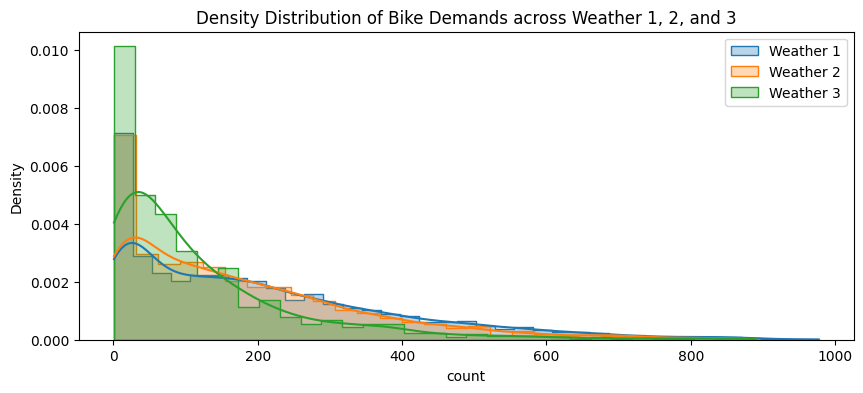

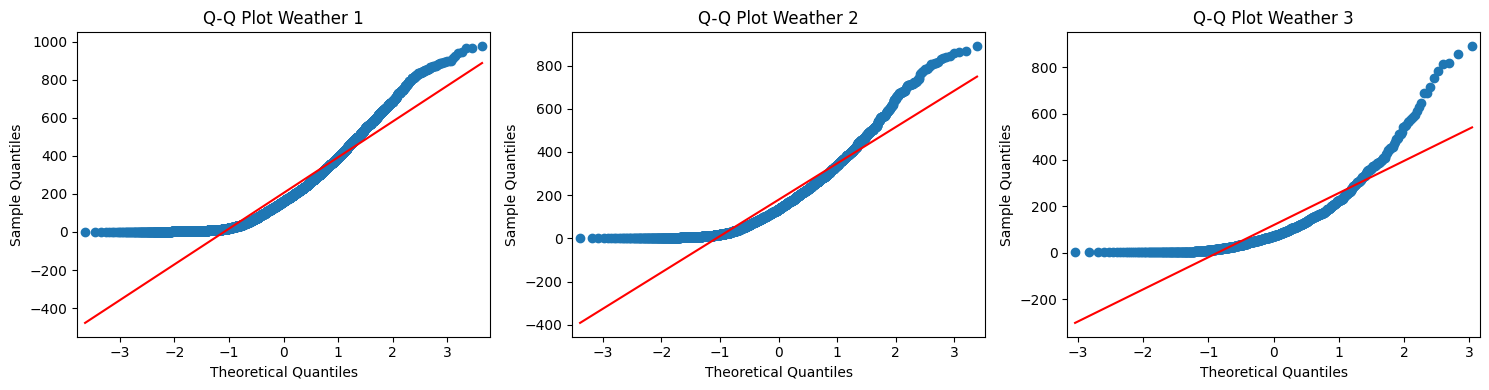

Levene's Test p-value: 6.198278710731511e-36


In [ ]:
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting groups 1, 2, and 3 only
w1 = df_after_drop[df_after_drop['weather'] == 1]['count']
w2 = df_after_drop[df_after_drop['weather'] == 2]['count']
w3 = df_after_drop[df_after_drop['weather'] == 3]['count']

# i. Normality Check (Using Histogram, Skewness, Kurtosis & Shapiro-Wilk)
for i, group in enumerate([w1, w2, w3], 1):
    print(f"Weather {i} -> Skewness: {group.skew().round(2)}, Kurtosis: {group.kurt().round(2)}")
    # Sampling 5000 records since Shapiro-Wilk is unstable for very large N
    print(f"Shapiro-Wilk p-value: {stats.shapiro(group.sample(min(len(group), 5000), random_state=42))[1]}")

# Visual Analysis of Normality
plt.figure(figsize=(10, 4))
for i, group in enumerate([w1, w2, w3], 1):
    sns.histplot(group, kde=True, label=f'Weather {i}', element='step', stat="density", alpha=0.3)
plt.title("Density Distribution of Bike Demands across Weather 1, 2, and 3")
plt.legend()
plt.show()

# Q-Q Plot for visual normality validation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, group in enumerate([w1, w2, w3], 1):
    sm.qqplot(group, line='s', ax=axes[i-1])
    axes[i-1].set_title(f'Q-Q Plot Weather {i}')
plt.tight_layout()
plt.show()

# ii. Equality of Variance (Levene’s test)
levene_stat, levene_p = stats.levene(w1, w2, w3)
print(f"Levene's Test p-value: {levene_p}")

Normalcy: Not successful. The Shapiro-Wilk $p$-values are significantly below $0.05$, and the text outputs display positive skewness values ($> 1$). The Q-Q plot points curve sharply away from the straight red trendline, and the histograms are visually strongly skewed to the right.

Variance Homogeneity: Not passed. Levene's test yields a $p$-value $< 0.05$, i.e. the variances are significantly different.

**Analysis: Demand of Bicycles vs. Seasons**

$H_0$ (Null Hypothesis): The mean number of rented bicycles are equal in all 4 seasons. ($ \mu_1 = \mu_2 = \mu_3 = \mu_4$)
$H_1$ (Alternate Hypothesis): There is at least one season with a significantly different average number of rented bicycles

Levene's Test for Seasons p-value: 1.0147116860043298e-118


/tmp/ipykernel_3775/3059255923.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='count', data=df_after_drop, palette='pastel')


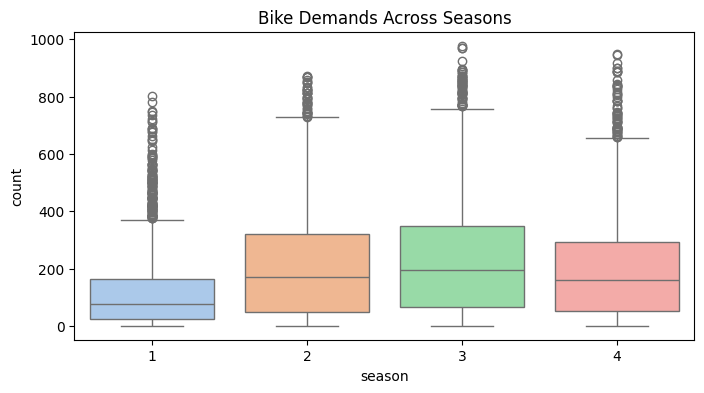

In [ ]:
s1 = df_after_drop[df_after_drop['season'] == 1]['count']
s2 = df_after_drop[df_after_drop['season'] == 2]['count']
s3 = df_after_drop[df_after_drop['season'] == 3]['count']
s4 = df_after_drop[df_after_drop['season'] == 4]['count']

# i. Normality & ii. Variance check
print(f"Levene's Test for Seasons p-value: {levene(s1, s2, s3, s4)[1]}")

plt.figure(figsize=(8, 4))
sns.boxplot(x='season', y='count', data=df_after_drop, palette='pastel')
plt.title("Bike Demands Across Seasons")
plt.show()

In [ ]:
f_stat_s, anova_p_s = f_oneway(s1, s2, s3, s4)
print(f"ANOVA Season p-value: {anova_p_s}")

k_stat_s, kruskal_p_s = kruskal(s1, s2, s3, s4)
print(f"Kruskal Season p-value: {kruskal_p_s}")

ANOVA Season p-value: 6.164843386499654e-149
Kruskal Season p-value: 2.479008372608633e-151


Decision: The $p$-value is effectively $0$ ($p \le 0.05$). We Reject the Null Hypothesis ($H_0$).

**Relationship Analysis: Weather Conditions vs. Seasons**

$H_0$ (Null Hypothesis) The weather conditions are independent of the seasons (no significant association).
$H_1$ (Alternate Hypothesis) The weather conditions are dependent on the seasons (there is a significant association).

In [ ]:
# Creating the Contingency Table
weather_season_crosstab = pd.crosstab(df_after_drop['weather'], df_after_drop['season'])
print("--- Contingency Table (Weather vs Season) ---")
print(weather_season_crosstab)
# Performing Chi-Square Test
chi2_stat, chi2_p, dof, expected = chi2_contingency(weather_season_crosstab)

print(f"\nChi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {chi2_p}")

--- Contingency Table (Weather vs Season) ---
season      1     2     3     4
weather                        
1        1759  1801  1930  1702
2         715   708   604   807
3         211   224   199   225
4           1     0     0     0

Chi-Square Statistic: 49.1587
P-value: 1.5499250736864862e-07


Decision: The resulting Chi-Square $p$-value is far less than $0.05$. We Reject $H_0$.

Conclusions & Recommendations
Inference: Weather and seasons are heavily dependent features. Some severe weather phenomena are confined to particular seasonal cycles in this operating market.

Recommendation Weather and seasonal trends should be combined simultaneously in predictive operational models rather than as separate individual signals. Yulu must leverage this seasonal weather pattern intelligence to plan macro-level inventory logistics and battery charging station infrastructure expansions.

Statistical Inference: The calculated $p$-value (0.526) is larger than our significance level ($\alpha = 0.05$) so we do not reject the Null Hypothesis ($H_0$). There is no statistical evidence that the average number of bike rentals on weekdays is less than the average number of rentals on weekends.
Operational Conclusion: The rental demand patterns indicate that the bike usage is still strong and stable throughout the week. Weekday demand is statistically same or slightly higher than the weekend demand. This means a sizeable part of Yulu’s user base depends on these e-cycles for routine, functional daily commutes (like office or college travel) and not just for leisure or recreational rides.

Dynamic Fleet Allocation: Given that weekday usage is primarily based on commuting behavior, we should focus on fully charging e-cycles and strategically placing them around high demand corporate hubs, metro stations, and residential areas at peak demand times (8:00 AM – 10:00 AM and 5:00 PM – 7:00 PM).

Targeted Marketing: In order to further increase weekday revenue, we can offer "Corporate Commute Pass" subscriptions, and/or discounts and partnerships to corporations that offer daily bundled rides to their commuters.

